C:\Users\user\AppData\Local\Temp\ipykernel_4500\438854067.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


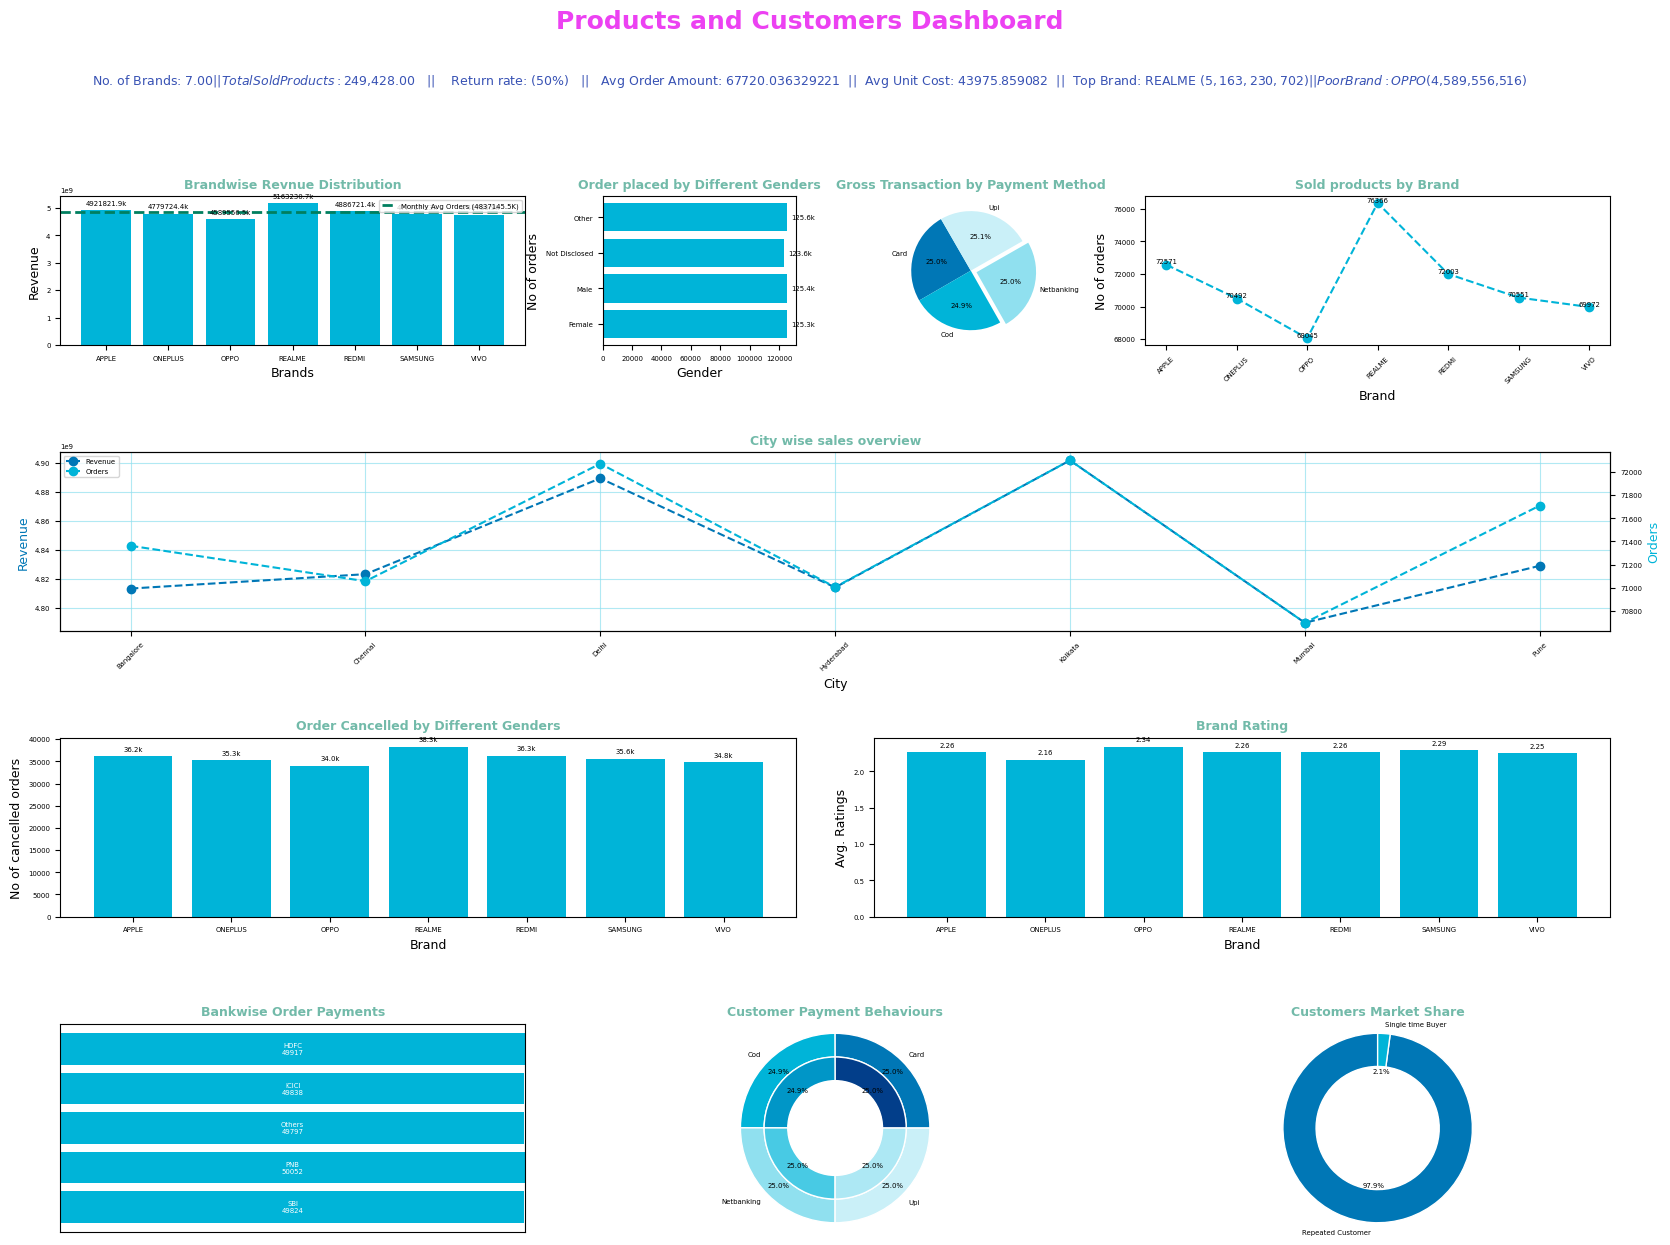

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df = pd.read_csv(r'D:\PYTHON PROJECTS\INDIAN SAMARTPHONE SALES MARKET\CLEANED DATASETS\main_order_table2.csv',encoding='latin1',low_memory=False)

# print(df.head(30))
# print(df.info())

# structure day & month
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['order_day_name'] = pd.Categorical(df['order_day_name'],categories=day_order,ordered=True)
df['order_month_name'] = pd.Categorical(df['order_month_name'],categories=month_order,ordered=True)

# Dashboard design
plt.rcParams.update({
    'font.size': 5,
    'axes.titlesize': 9,
    'axes.labelsize': 9
})

fig = plt.figure(figsize=(20,14))
gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    hspace=0.6,
    wspace=0.4,
    height_ratios=[1, 1.2, 1.2, 1.4]
)



# kpi
no_of_brands = len(df['brand'].unique())
no_sold_product = df.loc[df['order_status'].isin(['Delivered','Shipped']),:]      
no_sold_product = no_sold_product.shape[0]
no_returned_product = df.loc[df['order_status'].isin(['Cancelled']),:]
no_returned_product = no_returned_product.shape[0]
return_rate = (no_returned_product/no_sold_product)*100
avg_order_value = df['Total Bill'].mean()
avg_unit_cost = df['unit_price'].mean()
top_brand = df.groupby('brand').agg({'Total Bill':'sum'})
top_brand_name = top_brand['Total Bill'].idxmax()
top_brand_value = top_brand['Total Bill'].max()
low_brand_name = top_brand['Total Bill'].idxmin()
low_brand_value = top_brand['Total Bill'].min()

# Title
fig.text(
    0.5, 0.97,
    f"Products and Customers Dashboard",
    ha='center',
    fontsize=18,
    fontweight='bold',
    color='#EC41F2'
)

# KPI Line
fig.text(
    0.5, 0.93,
    f"No. of Brands: ${no_of_brands:,.2f}   ||    "
    f"Total Sold Products: ${no_sold_product:,.2f}   ||    "
    f"Return rate: ({return_rate:,.00f}%)   ||   "
    f"Avg Order Amount: {avg_order_value}  ||  "
    f"Avg Unit Cost: {avg_unit_cost}  ||  "
    f"Top Brand: {top_brand_name} (${top_brand_value:,.0f})   ||    "
    f"Poor Brand: {low_brand_name} (${low_brand_value:,.0f})",
    ha='center',
    fontsize=9,
    color='#3852B4'
)

plt.subplots_adjust(top=0.85)

# 1-Brand wise revenue
br_rev = df.groupby('brand').agg({'Total Bill':'sum'}).reset_index()

ax1 = fig.add_subplot(gs[0,0:2])

x1 = br_rev['brand']
y1 = br_rev['Total Bill']
avg_month_rev = br_rev['Total Bill'].mean()

ax1_bars = ax1.bar(x1,y1,color='#00b4d8')
ax1_label = [f'{v/1000:.1f}k' for v in y1]
ax1.bar_label(ax1_bars,labels=ax1_label,padding=3)
ax1.axhline(y=avg_month_rev, linestyle='--', linewidth=2,color='#007f5f',label=f'Monthly Avg Orders ({avg_month_rev/1000:.1f}K)')
ax1.set_xlabel('Brands')
ax1.set_ylabel('Revenue')
ax1.legend()
ax1.set_title('Brandwise Revnue Distribution',fontweight='bold',color='#72BAA9')


# Gender wise sales
gn_rev = df.groupby('gender').size().reset_index(name='count')

ax2 = fig.add_subplot(gs[0,2:3])

x2 = gn_rev['gender']
y2 = gn_rev['count']

ax2_bars = ax2.barh(x2,y2,color='#00b4d8')
ax2_label = [f'{v/1000:.1f}k' for v in y2]
ax2.bar_label(ax2_bars,labels=ax2_label,padding=3)
ax2.set_xlabel('Gender')
ax2.set_ylabel('No of orders')
ax2.set_title('Order placed by Different Genders',fontweight='bold',color='#72BAA9')


# 3-Pyment Method type(pie)
pt_rev = df.groupby('payment_method').agg({'Total Bill':'sum'}).reset_index()

ax3 = fig.add_subplot(gs[0,3:4])

ax3_values = pt_rev['Total Bill']
ax3_labels = pt_rev['payment_method']
ax3_col = ['#0077b6','#00b4d8','#90e0ef','#caf0f8']

ax3.pie(ax3_values,labels=ax3_labels,colors=ax3_col,explode=[0,0,0.1,0],autopct='%1.1f%%',startangle=120)
ax3.set_title('Gross Transaction by Payment Method',fontweight='bold',color='#72BAA9')


# 4-Total orders by brands
br_or = df.groupby('brand').size().reset_index(name='count')

ax4 =fig.add_subplot(gs[0,4:6])

x4 = br_or['brand']
y4 = br_or['count']

ax4_plot = ax4.plot(x4,y4,color='#00b4d8',marker='o',linestyle='--')
for xi, yi in zip(x4, y4):
    ax4.text(xi, yi, str(yi), ha='center', va='bottom')
ax4.set_xlabel('Brand')
ax4.set_ylabel('No of orders')
ax4.set_title('Sold products by Brand',fontweight='bold',color='#72BAA9')
ax4.tick_params(axis='x', rotation=45)


# 5-customer citywise revenue and order
ct_rev = df.groupby('city').agg({'Total Bill':'sum','order_id':'count'}).reset_index()

x5 = ct_rev['city']
y5 = ct_rev['Total Bill']
z5 = ct_rev['order_id']

ax5 = fig.add_subplot(gs[1,:])

ax5.plot(x5, y5, color='#0077b6', marker='o', linestyle='--', label='Revenue')
ax5.set_xlabel('City')
ax5.set_ylabel('Revenue', color='#0077b6')
ax5_2 = ax5.twinx()
ax5_2.plot(x5, z5, color='#00b4d8', marker='o', linestyle='--', label='Orders')
ax5_2.set_ylabel('Orders', color='#00b4d8')
ax5.set_title('City wise sales overview',fontweight='bold',color='#72BAA9')
ax5.grid(axis='both', color='#90e0ef', alpha=0.7)
ax5.tick_params(axis='x', rotation=45)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_2.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# 6-Cancelled orders brandwise
cn_or = df.loc[df['order_status'].isin(['Cancelled','Returned']),:]

br_cn_or = cn_or.groupby('brand').size().reset_index(name='count')

ax6 = fig.add_subplot(gs[2,0:3])

x6 = br_cn_or['brand']
y6 = br_cn_or['count']

ax6_bars = ax6.bar(x6,y6,color='#00b4d8')
ax6_label = [f'{v/1000:.1f}k' for v in y6]
ax6.bar_label(ax6_bars,labels=ax6_label,padding=3)
ax6.set_xlabel('Brand')
ax6.set_ylabel('No of cancelled orders')
ax6.set_title('Order Cancelled by Different Genders',fontweight='bold',color='#72BAA9')


# 7-Brand wise Ratings
br_ra = df.groupby('brand').agg({'rating_x':'mean'}).reset_index()

ax7 = fig.add_subplot(gs[2,3:6])

x7 = br_ra['brand']
y7 = br_ra['rating_x'].round(2)

ax7_bars = ax7.bar(x7,y7,color='#00b4d8')
ax7.bar_label(ax7_bars,padding=3)
ax7.set_xlabel('Brand')
ax7.set_ylabel('Avg. Ratings')
ax7.set_title('Brand Rating',fontweight='bold',color='#72BAA9')


# 8-payment_methodwise payments(funel chart)
sc_or = df.loc[df['order_status'].isin(['Delivered','Shipped']),:]
br_count = sc_or.groupby('bank').size().reset_index(name='count')

stages = br_count['bank'].values
values = br_count['count'].values

max_val = max(values)

ax8 = fig.add_subplot(gs[3,0:2])

for i, (stage, val) in enumerate(zip(stages, values)):
    width = val / max_val
    left = (1 - width) / 2  
    ax8.barh(i, width, left=left, color='#00b4d8')
    ax8.text(0.5, i, f"{stage}\n{val}", ha='center', va='center', color='white')

ax8.set_xlim(0, 1)
ax8.set_yticks([])
ax8.set_xticks([])
ax8.invert_yaxis()

ax8.set_title("Bankwise Order Payments",fontweight='bold', color='#72BAA9')


# 9-Payment methodwise rev(pie iner-outer chart)
pt_count = df.groupby('payment_method').size().reset_index(name='count')

labels = pt_count['payment_method']
values = pt_count['count']

ax9 = fig.add_subplot(gs[3, 2:4])

# Outer ring (main categories)
ax9.pie(values,
       labels=labels,
       radius=1.2,
       autopct='%1.1f%%',
       pctdistance=0.85,
       colors=['#0077b6','#00b4d8','#90e0ef','#caf0f8'],
       wedgeprops=dict(width=0.3, edgecolor='white'))

# Inner ring (same data or grouped data)
ax9.pie(values,
       radius=0.9,
       autopct='%1.1f%%',
       pctdistance=0.75,
       colors=['#023e8a','#0096c7','#48cae4','#ade8f4'],
       wedgeprops=dict(width=0.3, edgecolor='white'))

# Center circle (donut hole)
centre_circle = plt.Circle((0,0),0.6,fc='white')
ax9.add_artist(centre_circle)

ax9.set_title("Customer Payment Behaviours",
             fontweight='bold', color='#72BAA9')

ax9.axis('equal')


# 10-repeted customer vs single customer(dounat pie chart)
cus_bev = df.groupby('customer_id').size().reset_index(name='count')

def cus_st(x):
    if x>=2:
        return 'Repeated Customer'
    else:
        return 'Single time Buyer'
    
cus_bev['cus_st'] = cus_bev['count'].apply(cus_st)

cus = cus_bev.groupby('cus_st').size().reset_index(name='count')

ax10_labels = cus['cus_st']
ax10_values = cus['count']

ax10 = fig.add_subplot(gs[3, 4:6])

# Donut chart
wedges, texts, autotexts = ax10.pie(
    ax10_values,
    labels=ax10_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#0077b6', '#00b4d8'],
    wedgeprops=dict(width=0.35, edgecolor='white')
)

# Center hole
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
ax10.add_artist(centre_circle)
ax10.set_title("Customers Market Share",fontweight='bold', color='#72BAA9')

ax10.axis('equal')

plt.tight_layout(pad=0.3)
plt.show()
